In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'models'
d = current_dir
for _ in range(5):
    if (d / "models").exists() and (d / "simulations").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    src_path = str(project_root)
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    # Fallback to strict relative path just in case
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from utils.imports import *
from models.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:11<00:00, 4328.92it/s]


steps:  50000
conclusion:  0.5287356321839081
conclusion core 0.8205128205128205


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.857006,0.780732,0.740678,0.690757,0.018911,0.268176,0.681628,0.870792,0.247333,0.580988,...,0.195665,0.016545,0.202808,0.979045,0.531593,0.029335,0.579059,0.680497,0.131279,0.219636
1,0.858956,0.776596,0.740678,0.692463,0.019060,0.266609,0.681628,0.871689,0.247333,0.582934,...,0.195665,0.016675,0.202808,0.979531,0.533585,0.029335,0.582954,0.680497,0.132194,0.221010
2,0.858956,0.776596,0.728197,0.687329,0.019060,0.266609,0.679889,0.865294,0.247333,0.582934,...,0.194409,0.016545,0.202808,0.979531,0.537564,0.029335,0.581008,0.680497,0.132194,0.216905


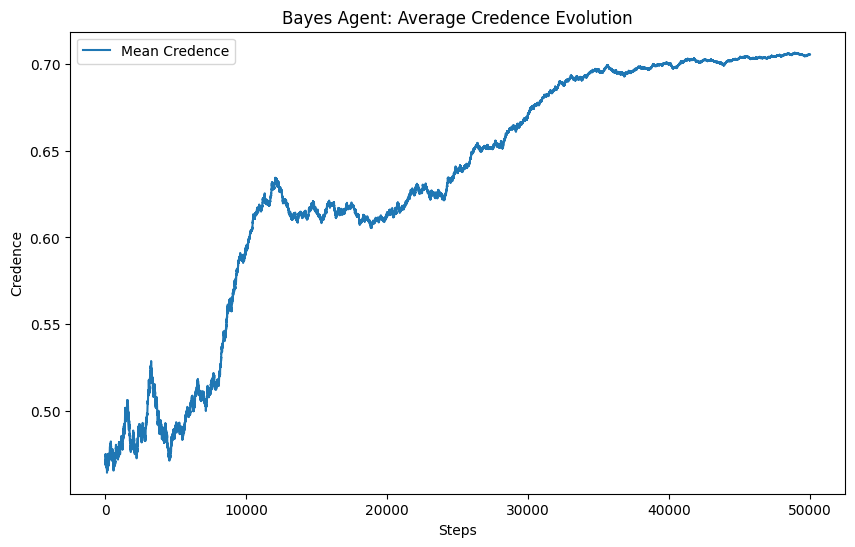

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

 72%|███████▏  | 7212/10000 [00:02<00:01, 2731.78it/s]


steps:  7213
conclusion:  0.6436781609195402


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,"[0.38505244578541514, 0.4120150484598234]","[0.9981628191623767, 1.3601884382221865e-05]","[0.9072007419813147, 0.9512866179439115]","[0.3824076291132812, 0.8507681972468842]","[0.3751945856357153, 0.49194043815928257]","[0.2862316712086527, 0.7952069045454606]","[0.34327183611803724, 0.46834477416001874]","[0.47002126430327945, 0.3480822090315836]","[0.5194295741519656, 1.0]","[0.2876349692505789, 0.1749378359927054]",...,"[0.7597565142217769, 0.0029960973273789023]","[0.7741943301596579, 0.8891067968790018]","[0.918273882864555, 0.39626163869056535]","[0.16440944800388516, 0.4856351301880446]","[0.8825228383233379, 0.7998916164192131]","[0.034215539033246374, 0.3907315983764219]","[0.5418325058709598, 0.7119180374262666]","[1.595981875905788e-05, 0.34338977048110736]","[0.2622913160381656, 0.5447900634203358]","[0.32272818004873305, 0.9563702575110261]"
1,"[0.690013340641364, 0.49343697329451086]","[0.3150983311583481, 0.3481364556843]","[0.7625295169921577, 0.6784893366122114]","[0.3044391047266125, 0.5111629870217022]","[0.7480219820042546, 0.568972515287642]","[0.13310981122590737, 0.5896259289343044]","[0.6699359601111523, 0.6261524408556388]","[0.65748126134393, 0.6238782353303205]","[0.4804723564797291, 0.7966901106644773]","[0.7799617434926011, 0.32330590551824473]",...,"[0.5339451009156297, 0.520051821526599]","[0.657057301081383, 0.44775728379885277]","[0.3576097827437357, 0.6068043421623706]","[0.6810693750414801, 0.5244957106666878]","[0.5556445534156105, 0.1844875370562006]","[0.428108484790529, 0.10384109608032145]","[0.5982609340333676, 0.4672957267652196]","[0.74993118844895, 0.47438725681953414]","[0.43634450302181765, 0.3730449000491975]","[0.7023672073614097, 0.6600662893540233]"
2,"[0.473012572115911, 0.5610661897445072]","[0.6607302793056969, 0.3258797300130006]","[0.5092181110014077, 0.7223713316788961]","[0.46670467570375235, 0.741376655805552]","[0.5321186119711255, 0.6330955250998894]","[0.8092080842349477, 0.580946996128451]","[0.596349552815593, 0.639060079967593]","[0.5332170792060766, 0.5455015658419131]","[0.4619662613578837, 0.763064809296128]","[0.5147217793670009, 0.16834690514200307]",...,"[0.5454689533531587, 0.354168641283015]","[0.3902946568839966, 0.5582224833228574]","[0.3668738186922359, 0.6522863001955833]","[0.5066131296182697, 0.451515161287965]","[0.4489727211510738, 0.6585518271879042]","[0.40235437164012905, 0.4393648899956346]","[0.5326207072422365, 0.3494292918506017]","[0.6566670477741648, 0.6272777613578417]","[0.40547524224473147, 0.5635282490123952]","[0.5993241622807789, 0.641453972109232]"


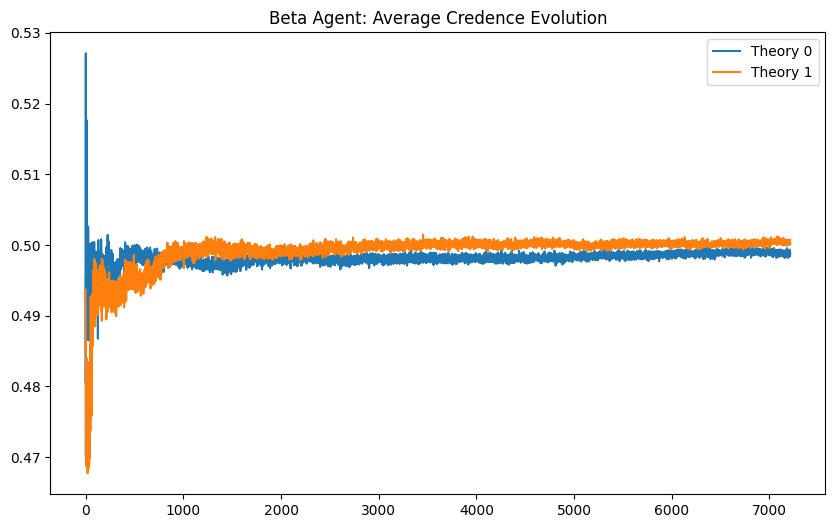

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

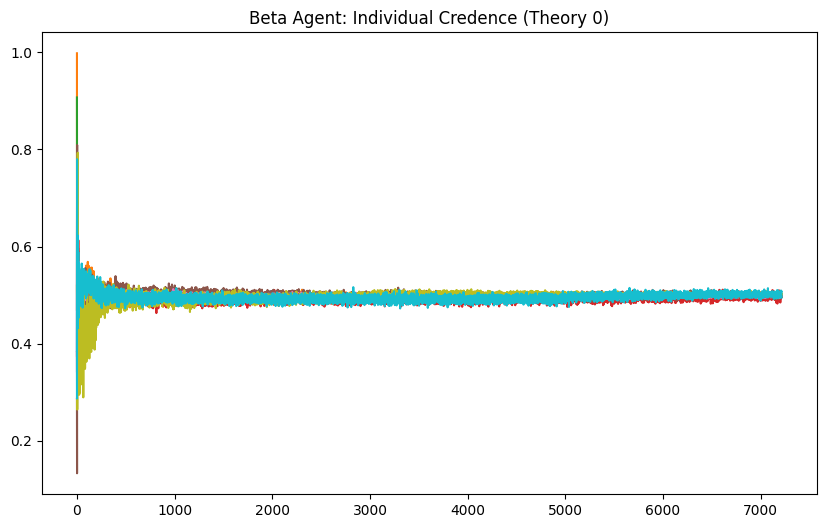

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()